In [ ]:
!pip install torch torchvision matplotlib numpy pandas scipy tensorboard transformers

import torch, os, numpy as np, pandas as pd, shutil
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from scipy.interpolate import make_interp_spline

# CLIP (via transformers)
from transformers import CLIPProcessor, CLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

os.makedirs("outputs", exist_ok=True)

writer = SummaryWriter("runs/jscc")

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda') if use_amp else None

print("Device:", device)

Device: cuda


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

classes = trainset.classes

100%|██████████| 170M/170M [00:04<00:00, 35.2MB/s]


In [ ]:
def ssim_loss(x,y):
    C1,C2=0.01**2,0.03**2
    mu_x=F.avg_pool2d(x,3,1,1)
    mu_y=F.avg_pool2d(y,3,1,1)
    sigma_x=F.avg_pool2d(x*x,3,1,1)-mu_x**2
    sigma_y=F.avg_pool2d(y*y,3,1,1)-mu_y**2
    sigma_xy=F.avg_pool2d(x*y,3,1,1)-mu_x*mu_y
    return 1-(((2*mu_x*mu_y+C1)*(2*sigma_xy+C2))/((mu_x**2+mu_y**2+C1)*(sigma_x+sigma_y+C2))).mean()

def edge_loss(x,y):
    sobel_x=torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]],device=x.device).float().view(1,1,3,3)
    sobel_y=torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]],device=x.device).float().view(1,1,3,3)

    sobel_x=sobel_x.repeat(x.size(1),1,1,1)
    sobel_y=sobel_y.repeat(x.size(1),1,1,1)

    gx=F.conv2d(x,sobel_x,padding=1,groups=x.size(1))
    gy=F.conv2d(x,sobel_y,padding=1,groups=x.size(1))
    ex=torch.sqrt(gx**2+gy**2+1e-6)

    gx=F.conv2d(y,sobel_x,padding=1,groups=y.size(1))
    gy=F.conv2d(y,sobel_y,padding=1,groups=y.size(1))
    ey=torch.sqrt(gx**2+gy**2+1e-6)

    return torch.mean(torch.abs(ex-ey))

vgg=models.vgg16(pretrained=True).features[:16].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual_loss(x,y):
    return torch.mean((vgg(x)-vgg(y))**2)

def psnr(x,y):
    mse=torch.mean((x-y)**2)
    return 20*torch.log10(1.0/torch.sqrt(mse+1e-8))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 161MB/s]


In [ ]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

for p in clip_model.parameters():
    p.requires_grad = False

def clip_loss(images, labels):
    texts = [classes[l] for l in labels.cpu().numpy()]
    inputs = clip_processor(text=texts, images=images, return_tensors="pt", padding=True).to(device)
    outputs = clip_model(**inputs)
    logits = outputs.logits_per_image
    return torch.mean(1 - torch.diag(F.softmax(logits, dim=1)))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
class Encoder(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(3,32,3,2,1),nn.ReLU(),
            nn.Conv2d(32,64,3,2,1),nn.ReLU(),
            nn.Conv2d(64,128,3,2,1),nn.ReLU()
        )
        self.fc=nn.Linear(128*4*4,dim)

    def forward(self,x):
        x=self.net(x)
        return self.fc(x.view(x.size(0),-1))

class Decoder(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.fc=nn.Linear(dim,128*4*4)
        self.net=nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1),nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(self.fc(x).view(-1,128,4,4))

class JSCC(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.enc=Encoder(dim)
        self.dec=Decoder(dim)
        self.classifier = nn.Linear(dim, 10)  # 🔥 semantic head

    def forward(self,x,snr):
        z=self.enc(x)
        noisy=z + torch.randn_like(z)*(10**(-snr/20))
        out=self.dec(noisy)
        logits=self.classifier(z)
        return out, logits

In [ ]:
def train_model(model,opt,epochs,model_id):
    ce_loss = nn.CrossEntropyLoss()

    for ep in range(epochs):
        total=0
        for img,labels in trainloader:
            img,labels=img.to(device),labels.to(device)
            snr=np.random.choice([0,5,10,15,20])

            opt.zero_grad()

            if use_amp:
                with torch.amp.autocast('cuda'):
                    out, logits = model(img,snr)

                    loss = (
                        0.4*ssim_loss(out,img) +
                        0.2*torch.mean(torch.abs(out-img)) +
                        0.1*edge_loss(out,img) +
                        0.1*perceptual_loss(out,img) +
                        0.1*ce_loss(logits, labels) +       # semantic classification
                        0.1*clip_loss(out, labels)          # CLIP semantic alignment
                    )
            else:
                out, logits = model(img,snr)
                loss = (
                    0.4*ssim_loss(out,img) +
                    0.2*torch.mean(torch.abs(out-img)) +
                    0.1*edge_loss(out,img) +
                    0.1*perceptual_loss(out,img) +
                    0.1*ce_loss(logits, labels) +
                    0.1*clip_loss(out, labels)
                )

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                opt.step()

            total+=loss.item()

        avg=total/len(trainloader)
        writer.add_scalar(f"Loss/model_{model_id}",avg,ep)
        print(f"Model {model_id} Epoch {ep+1} Loss {avg:.4f}")

In [ ]:
configs=[32,64,96]

all_models=[]

for i,ld in enumerate(configs):
    model=JSCC(ld).to(device)
    opt=optim.Adam(model.parameters(),1e-3)

    train_model(model,opt,2,i)   # fast search

    ssim_val=0
    with torch.no_grad():
        for img,_ in testloader:
            img=img.to(device)
            out,_=model(img,10)
            ssim_val+=(1-ssim_loss(out,img)).item()

    ssim_val/=len(testloader)

    path=f"outputs/temp_{ld}.pth"
    torch.save(model.state_dict(),path)

    all_models.append((ssim_val,path,ld))

all_models=sorted(all_models,key=lambda x:-x[0])

# Save top-3
for i in range(len(all_models)):
    shutil.copy(all_models[i][1],f"outputs/top_{i+1}_ld{all_models[i][2]}.pth")

best_ld=all_models[0][2]
print("BEST latent_dim:",best_ld)

Model 0 Epoch 1 Loss 1.2337
Model 0 Epoch 2 Loss 1.0735
Model 1 Epoch 1 Loss 1.2308
Model 1 Epoch 2 Loss 1.0417
Model 2 Epoch 1 Loss 1.2291
Model 2 Epoch 2 Loss 1.0302
BEST latent_dim: 96


In [ ]:
best_model=JSCC(best_ld).to(device)
opt=optim.Adam(best_model.parameters(),1e-3)

train_model(best_model,opt,5,"BEST")

torch.save(best_model.state_dict(),"outputs/best_model.pth")

Model BEST Epoch 1 Loss 1.2331
Model BEST Epoch 2 Loss 1.0362
Model BEST Epoch 3 Loss 0.9367
Model BEST Epoch 4 Loss 0.8761
Model BEST Epoch 5 Loss 0.8282


In [ ]:
def final_semantic_plot(model):
    model.eval()

    snrs = [0,5,10,15,20]
    ssim_vals = []
    acc_vals = []

    for snr in snrs:
        ssim_total = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for img, labels in testloader:
                img, labels = img.to(device), labels.to(device)

                out, logits = model(img, snr)

                # SSIM
                ssim_total += (1 - ssim_loss(out, img)).item()

                # Accuracy
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        ssim_vals.append(ssim_total / len(testloader))
        acc_vals.append(correct / total)

    # Smooth curves
    snr_dense = np.linspace(min(snrs), max(snrs), 200)
    ssim_smooth = make_interp_spline(snrs, ssim_vals)(snr_dense)
    acc_smooth = make_interp_spline(snrs, acc_vals)(snr_dense)

    # Plot
    fig, ax1 = plt.subplots(figsize=(7,4), dpi=300)

    ax1.plot(snr_dense, ssim_smooth, label="SSIM", linewidth=2)
    ax1.scatter(snrs, ssim_vals)
    ax1.set_xlabel("SNR (dB)")
    ax1.set_ylabel("SSIM")

    ax2 = ax1.twinx()
    ax2.plot(snr_dense, acc_smooth, linestyle='--', label="Accuracy")
    ax2.scatter(snrs, acc_vals)
    ax2.set_ylabel("Classification Accuracy")

    plt.title("Semantic Communication Performance")
    plt.grid()

    plt.savefig("outputs/final_semantic_plot.png", dpi=300)
    plt.show()

In [ ]:
from matplotlib.gridspec import GridSpec

def semantic_visualization(model):
    model.eval()

    imgs, labels = next(iter(testloader))
    imgs, labels = imgs.to(device), labels.to(device)

    with torch.no_grad():
        out_low, logits_low = model(imgs, 0)
        out_high, logits_high = model(imgs, 20)

    imgs = imgs.cpu()
    out_low = out_low.cpu()
    out_high = out_high.cpu()

    preds_low = torch.argmax(logits_low, dim=1).cpu()
    preds_high = torch.argmax(logits_high, dim=1).cpu()

    fig = plt.figure(figsize=(12,6), dpi=300)
    gs = GridSpec(3,4, figure=fig)

    for i in range(3):
        # Original
        ax = fig.add_subplot(gs[i,0])
        ax.imshow(imgs[i].permute(1,2,0))
        ax.set_title(f"GT: {classes[labels[i]]}")
        ax.axis('off')

        # Low SNR
        ax = fig.add_subplot(gs[i,1])
        ax.imshow(out_low[i].permute(1,2,0))
        ax.set_title(f"SNR=0\nPred: {classes[preds_low[i]]}")
        ax.axis('off')

        # High SNR
        ax = fig.add_subplot(gs[i,2])
        ax.imshow(out_high[i].permute(1,2,0))
        ax.set_title(f"SNR=20\nPred: {classes[preds_high[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.savefig("outputs/semantic_visualization.png", dpi=300)
    plt.show()

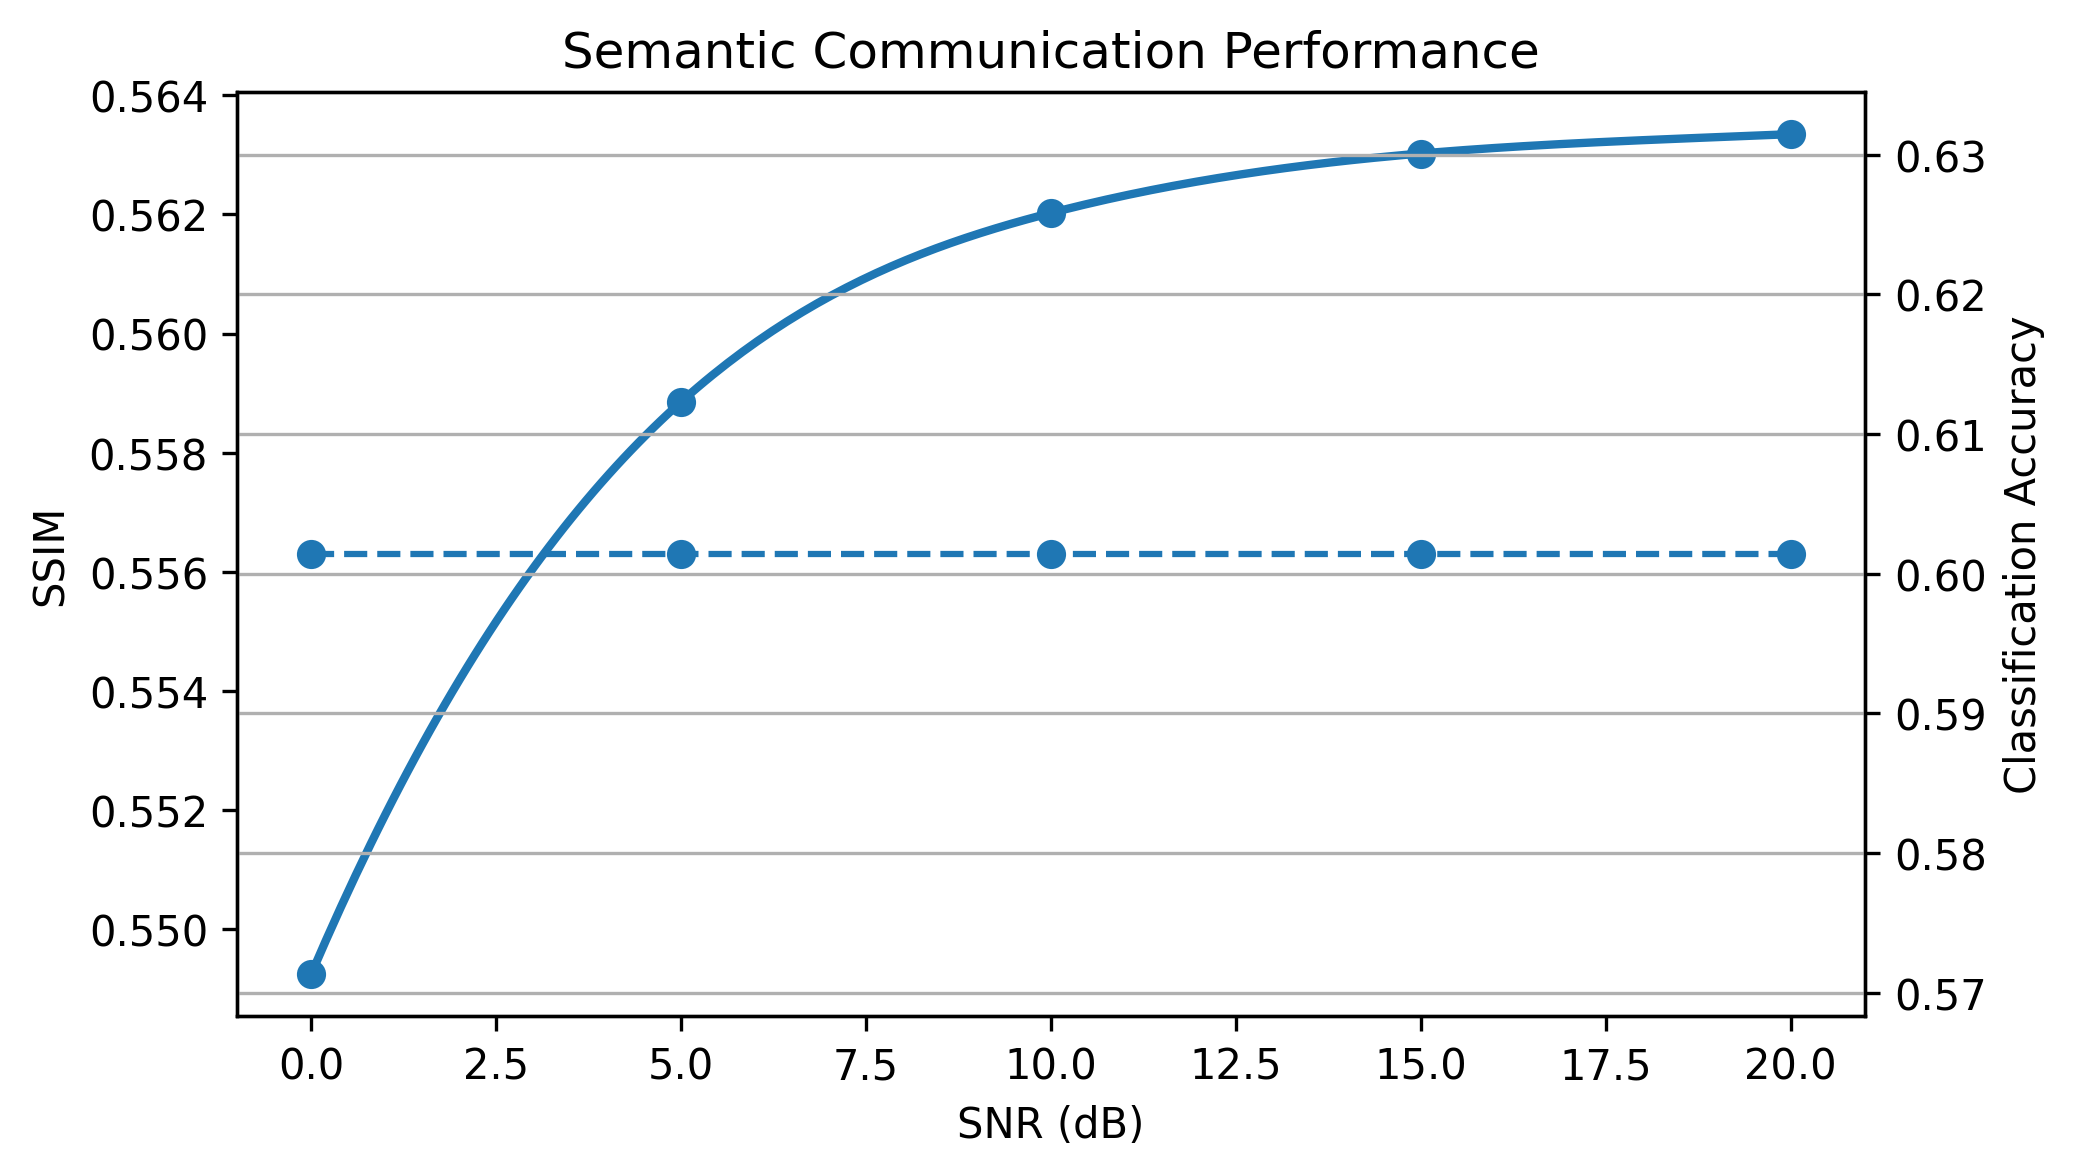

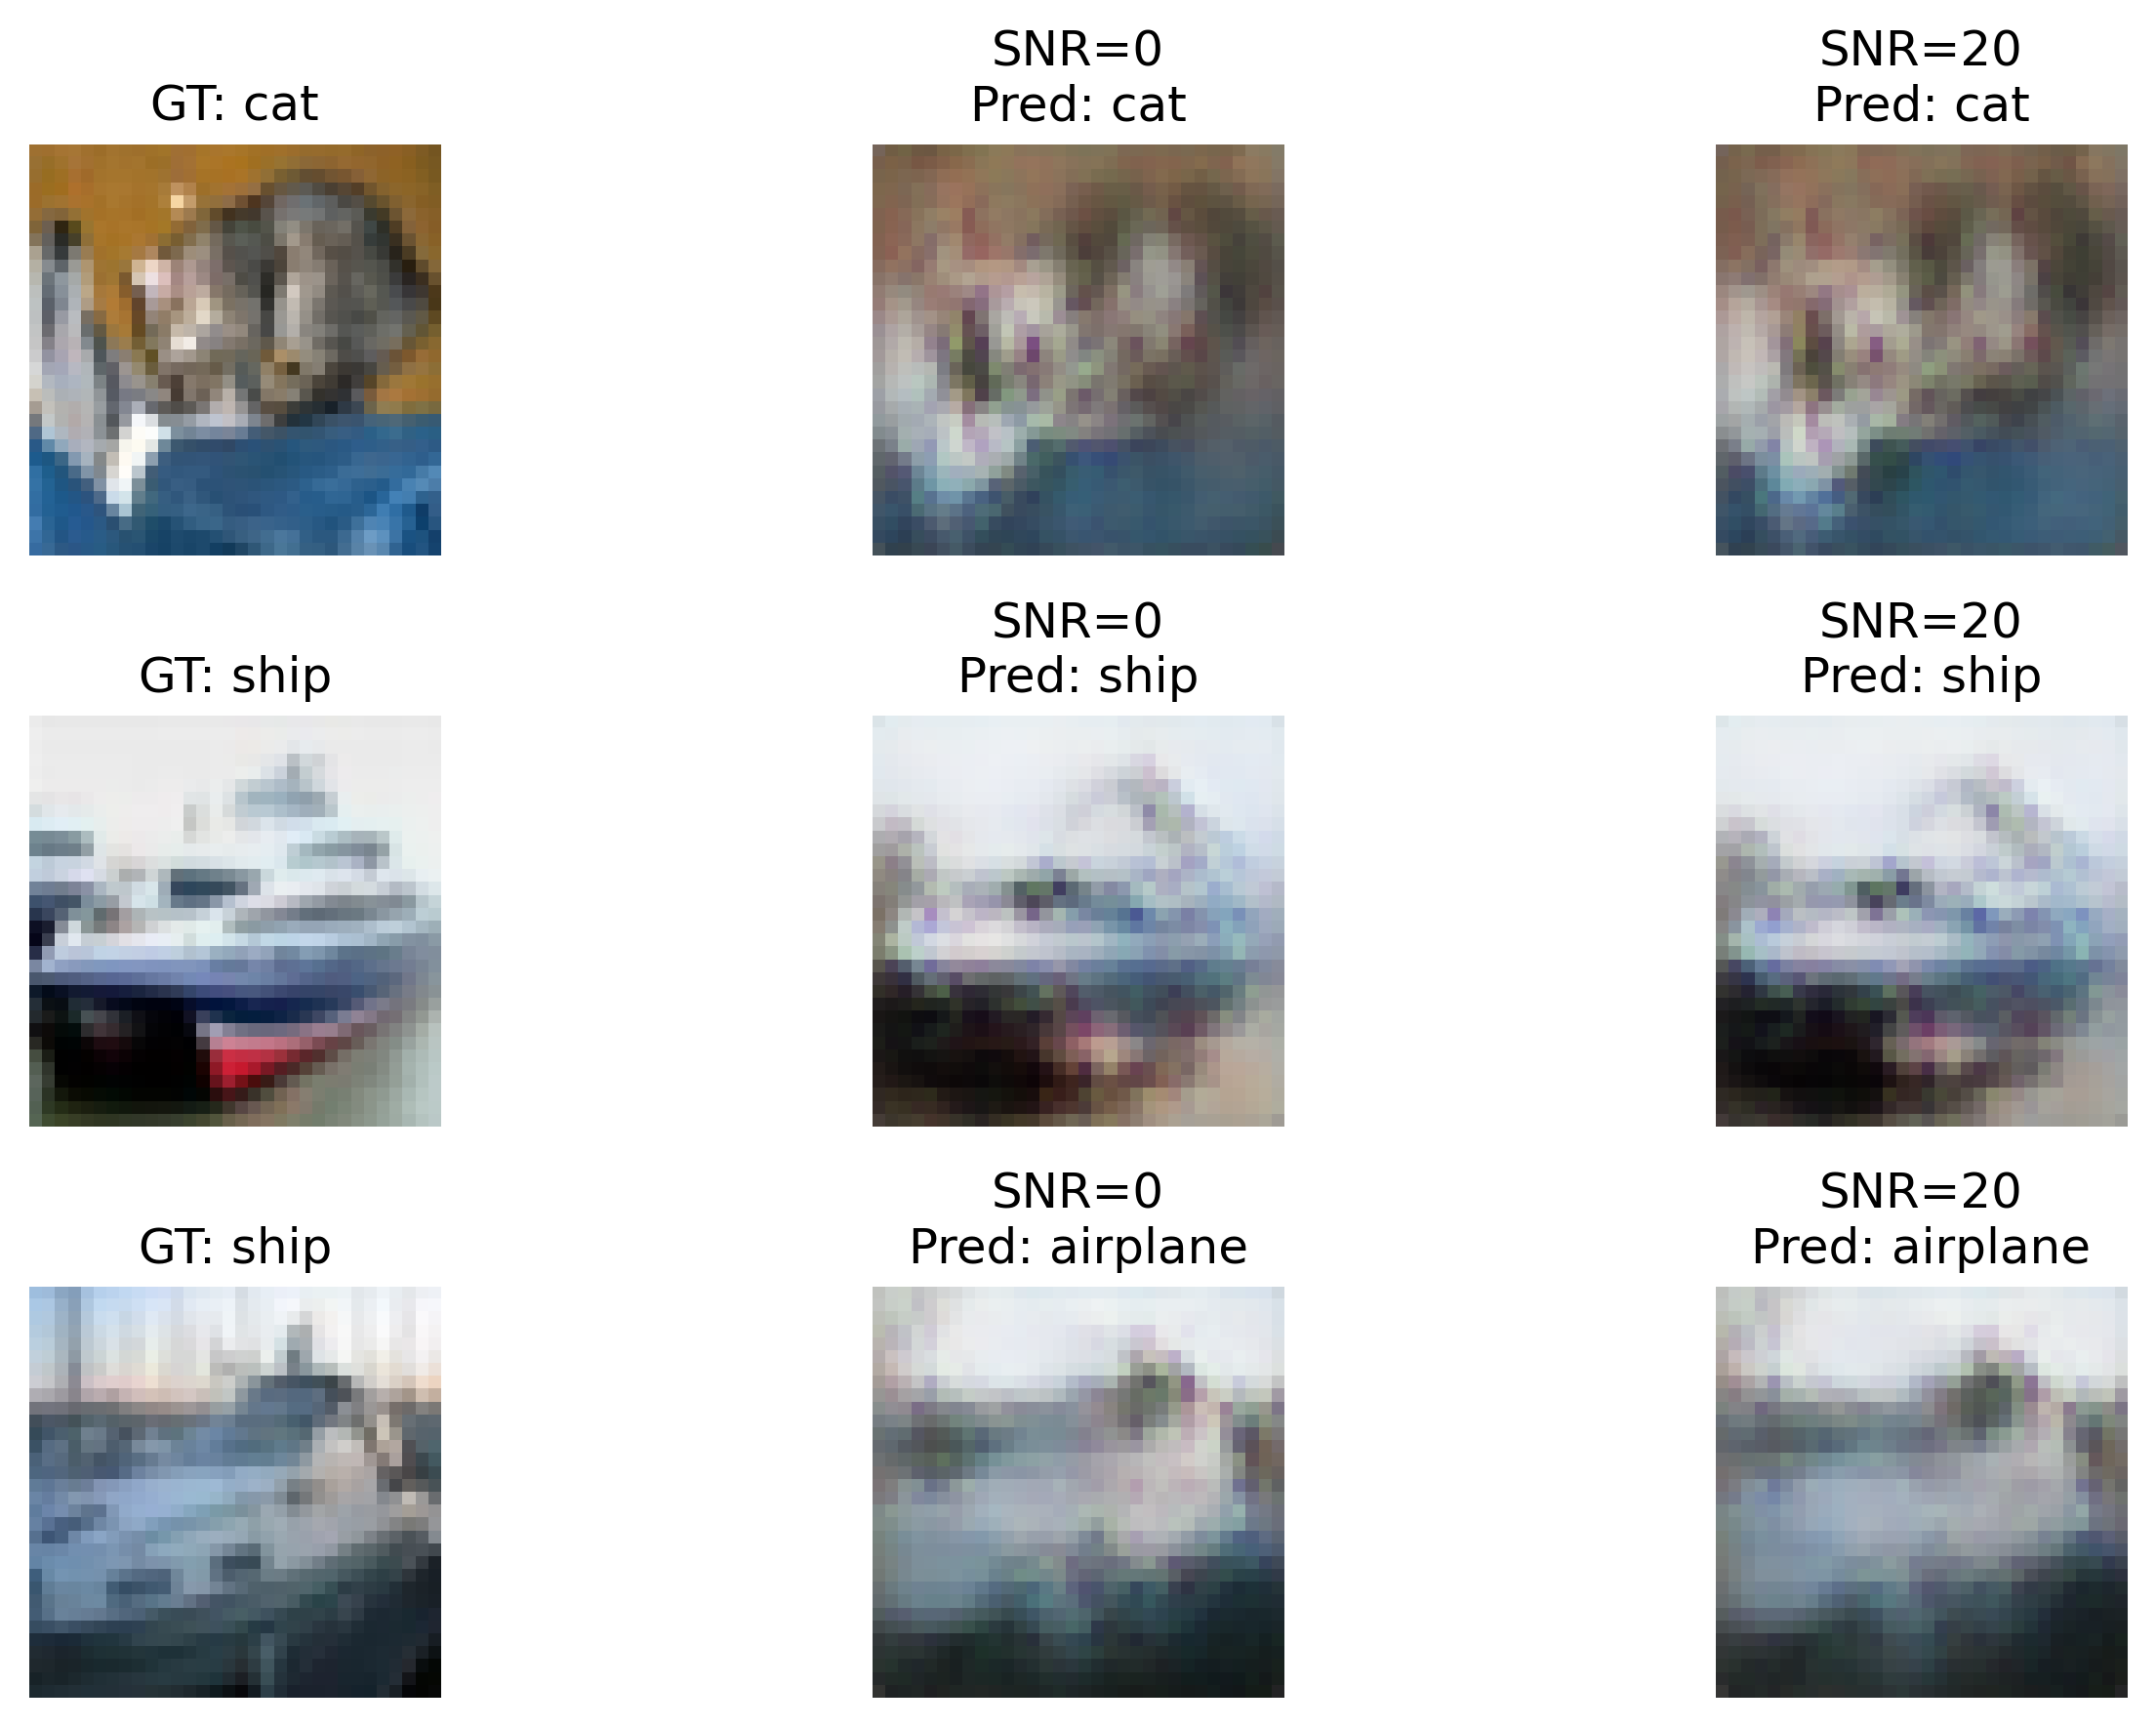

In [ ]:
final_semantic_plot(best_model)
semantic_visualization(best_model)